In [1]:
# ===============================
# Install Required Packages
# ===============================

!pip install bert-score
!pip install nltk
!pip install sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 18.4 MB/s eta 0:00:00


In [2]:
# ============================================================
# Sanskrit to English Neural Machine Translation
# Assignment - Natural Language Understanding
# ============================================================

import os
import re
import time
import math
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bert_score
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

# --------------------------------------------------------
# Device Configuration
# --------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device :", device)

Using Device : cuda


In [3]:
# --------------------------------------------------------
# Reproducibility
# --------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# --------------------------------------------------------
# Load Dataset
# --------------------------------------------------------

train_sa = pd.read_csv("train_sa_10000 (1).csv")
train_en = pd.read_csv("train_en_10000 (1).csv")

dev_sa = pd.read_csv("dev_sa_1000 (1).csv")
dev_en = pd.read_csv("dev_en_1000 (1).csv")

test_sa = pd.read_csv("test_sa_1000 (1).csv")
test_en = pd.read_csv("test_en_1000 (1).csv")

In [5]:
train = pd.merge(
    train_sa,
    train_en,
    on="Source_id"
)
dev = pd.merge(
    dev_sa,
    dev_en,
    on="Source_id"
)
test = pd.merge(
    test_sa,
    test_en,
    on="Source_id"
)

In [6]:
print("Training :", train.shape)
print("Validation :", dev.shape)
print("Testing :", test.shape)

train.head()

Training : (10000, 3)
Validation : (1000, 3)
Testing : (1000, 3)


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


In [7]:
# --------------------------------------------------------
# Sanskrit Cleaning
# --------------------------------------------------------

def clean_sanskrit(sentence):
  sentence = str(sentence)
  sentence = sentence.replace("।", " ")
  sentence = sentence.replace("॥", " ")
  sentence = re.sub(r"\s+", " ", sentence)
  sentence = sentence.strip()
  return sentence

In [8]:
# --------------------------------------------------------
# English Cleaning
# --------------------------------------------------------

def clean_english(sentence):
  sentence = str(sentence)
  sentence = sentence.lower()
  sentence = re.sub(r"[^a-zA-Z ]", " ", sentence)
  sentence = re.sub(r"\s+", " ", sentence)
  sentence = sentence.strip()
  return sentence

In [9]:
train["Sentence_sa"] = train["Sentence_sa"].apply(clean_sanskrit)
train["Sentence_en"] = train["Sentence_en"].apply(clean_english)

dev["Sentence_sa"] = dev["Sentence_sa"].apply(clean_sanskrit)
dev["Sentence_en"] = dev["Sentence_en"].apply(clean_english)

test["Sentence_sa"] = test["Sentence_sa"].apply(clean_sanskrit)
test["Sentence_en"] = test["Sentence_en"].apply(clean_english)

In [10]:
def tokenize(sentence):
  return sentence.split()

In [11]:
print(tokenize(train.iloc[0]["Sentence_sa"]))
print(tokenize(train.iloc[0]["Sentence_en"]))

['"Ctrl,', 'S', 'नुत्वा', 'रक्षन्तु', '"']
['save', 'it', 'with', 'ctrl', 's']


In [12]:
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

In [13]:
class Vocabulary:

  def __init__(self, min_freq=2):
    self.min_freq = min_freq
    self.word2idx = {
        PAD_TOKEN:0,
        SOS_TOKEN:1,
        EOS_TOKEN:2,
        UNK_TOKEN:3
    }
    self.idx2word = {
        0:PAD_TOKEN,
        1:SOS_TOKEN,
        2:EOS_TOKEN,
        3:UNK_TOKEN
    }

  def build_vocab(self, sentences):
    counter = Counter()
    for sentence in sentences:
      counter.update(tokenize(sentence))

    index = 4
    for word, freq in counter.items():
      if freq >= self.min_freq:
        self.word2idx[word] = index
        self.idx2word[index] = word
        index += 1

  def numericalize(self, sentence):
    tokens = tokenize(sentence)
    ids = []
    for token in tokens:
      ids.append(
          self.word2idx.get(
              token,
              self.word2idx[UNK_TOKEN]
          )
      )

    return ids

  def __len__(self):
    return len(self.word2idx)

In [14]:
src_vocab = Vocabulary(min_freq=1)
tgt_vocab = Vocabulary(min_freq=1)

src_vocab.build_vocab(train["Sentence_sa"])
tgt_vocab.build_vocab(train["Sentence_en"])

print("Source Vocabulary:", len(src_vocab))
print("Target Vocabulary:", len(tgt_vocab))

for i in range(20):
  print(i, tgt_vocab.idx2word[i])


Source Vocabulary: 32569
Target Vocabulary: 9939
0 <pad>
1 <sos>
2 <eos>
3 <unk>
4 save
5 it
6 with
7 ctrl
8 s
9 teacher
10 will
11 teach
12 the
13 students
14 only
15 once
16 to
17 recreate
18 this
19 animation


In [15]:
class TranslationDataset(Dataset):

  def __init__(

      self,

      dataframe,

      src_vocab,

      tgt_vocab

  ):
    self.data = dataframe

    self.src_vocab = src_vocab

    self.tgt_vocab = tgt_vocab

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    src_sentence = clean_sanskrit(self.data.iloc[index]["Sentence_sa"])
    tgt_sentence = clean_english(self.data.iloc[index]["Sentence_en"])

    src = [self.src_vocab.word2idx[SOS_TOKEN]]
    src += self.src_vocab.numericalize(src_sentence)
    src.append(self.src_vocab.word2idx[EOS_TOKEN])

    tgt = [self.tgt_vocab.word2idx[SOS_TOKEN]]
    tgt += self.tgt_vocab.numericalize(tgt_sentence)
    tgt.append(self.tgt_vocab.word2idx[EOS_TOKEN])

    return torch.tensor(src), torch.tensor(tgt)

In [16]:
PAD_SRC = src_vocab.word2idx[PAD_TOKEN]
PAD_TGT = tgt_vocab.word2idx[PAD_TOKEN]

In [17]:
def collate_fn(batch):
  src = [item[0] for item in batch]
  tgt = [item[1] for item in batch]

  src_lengths = torch.tensor([len(sentence) for sentence in src])
  src = nn.utils.rnn.pad_sequence(
      src,
      batch_first=True,
      padding_value=PAD_SRC
  )
  tgt = nn.utils.rnn.pad_sequence(
      tgt,
      batch_first=True,
      padding_value=PAD_TGT
  )
  return src, src_lengths, tgt

In [18]:
BATCH_SIZE = 128

train_dataset = TranslationDataset(
    train,
    src_vocab,
    tgt_vocab
)
dev_dataset = TranslationDataset(
    dev,
    src_vocab,
    tgt_vocab
)
test_dataset = TranslationDataset(
    test,
    src_vocab,
    tgt_vocab
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)
print("Data Loaders Created Successfully")

Data Loaders Created Successfully


In [19]:
src_batch, src_lengths_batch, tgt_batch = next(iter(train_loader))

print("Source Batch Shape :", src_batch.shape)
print("Source Lengths Batch Shape :", src_lengths_batch.shape)
print("Target Batch Shape :", tgt_batch.shape)

Source Batch Shape : torch.Size([128, 37])
Source Lengths Batch Shape : torch.Size([128])
Target Batch Shape : torch.Size([128, 40])


In [20]:
# ============================================================
# Hyperparameters
# ============================================================

INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(tgt_vocab)

ENC_EMB_DIM = 512
DEC_EMB_DIM = 512

HIDDEN_DIM = 512

NUM_LAYERS = 2

ENC_DROPOUT = 0.4
DEC_DROPOUT = 0.4

In [21]:
# ============================================================
# Bidirectional LSTM Encoder
# ============================================================

class Encoder(nn.Module):

  def __init__(
      self,
      input_dim,
      emb_dim,
      hidden_dim,
      num_layers,
      dropout
  ):
    super().__init__()
    self.embedding = nn.Embedding(
        input_dim,
        emb_dim,
        padding_idx=PAD_SRC
    )
    self.dropout = nn.Dropout(dropout)
    self.lstm = nn.LSTM(
        emb_dim,
        hidden_dim,
        num_layers=num_layers,
        batch_first=True,
        dropout=dropout,
        bidirectional=True
    )
    self.fc_hidden = nn.Linear(
        hidden_dim * 2,
        hidden_dim
    )
    self.fc_cell = nn.Linear(
        hidden_dim * 2,
        hidden_dim
    )

  def forward(self, src, src_lengths):
    embedded = self.dropout(self.embedding(src))
    packed = nn.utils.rnn.pack_padded_sequence(
        embedded,
        src_lengths.cpu(),
        batch_first=True,
        enforce_sorted=False
    )
    packed_outputs, (hidden, cell) = self.lstm(packed)
    outputs, _ = nn.utils.rnn.pad_packed_sequence(
        packed_outputs,
        batch_first=True,
        total_length=src.size(1)
    )
    hidden_cat = []
    cell_cat = []
    for i in range(0, hidden.size(0), 2):
      hidden_cat.append(
          torch.tanh(
              self.fc_hidden(
                  torch.cat(
                      (hidden[i], hidden[i + 1]),
                      dim=1
                  )
              )
          )
      )
      cell_cat.append(
          torch.tanh(
              self.fc_cell(
                  torch.cat(
                      (cell[i], cell[i + 1]),
                      dim=1
                  )
              )
          )
      )
    hidden = torch.stack(hidden_cat)
    cell = torch.stack(cell_cat)
    return outputs, hidden, cell

In [22]:
# ============================================================
# Bahdanau Attention
# ============================================================

class Attention(nn.Module):

  def __init__(self, hidden_dim):
    super().__init__()
    self.attn = nn.Linear(
        hidden_dim * 3,
        hidden_dim
    )
    self.v = nn.Linear(
        hidden_dim,
        1,
        bias=False
    )

  def forward(self,hidden,encoder_outputs,mask):
    batch_size = encoder_outputs.shape[0]
    src_len = encoder_outputs.shape[1]
    hidden = hidden.unsqueeze(1)
    hidden = hidden.repeat(1,src_len,1)
    energy = torch.tanh(
        self.attn(
            torch.cat(
                (hidden,encoder_outputs),
                dim=2
            )
        )
    )
    attention = self.v(energy).squeeze(2)
    attention = attention.masked_fill(mask == 0,-1e10)
    return torch.softmax(attention,dim=1)

In [23]:
# ============================================================
# LSTM Decoder
# ============================================================

class Decoder(nn.Module):

  def __init__(self,output_dim,emb_dim,hidden_dim,num_layers,dropout,attention):
    super().__init__()
    self.output_dim = output_dim
    self.attention = attention
    self.embedding = nn.Embedding(
        output_dim,
        emb_dim,
        padding_idx=PAD_TGT
    )
    self.num_layers = num_layers
    self.dropout = nn.Dropout(dropout)
    self.lstm = nn.LSTM(
        input_size=emb_dim + hidden_dim * 2,
        hidden_size=hidden_dim,
        num_layers=num_layers,
        dropout=dropout if num_layers > 1 else 0,
        batch_first=True
    )
    self.fc = nn.Linear(
        hidden_dim * 3 + emb_dim,
        output_dim
    )

  def forward(self,input,hidden,cell,encoder_outputs,mask):
    input = input.unsqueeze(1)
    embedded = self.dropout(self.embedding(input))
    attention = self.attention(
        hidden[-1],
        encoder_outputs,
        mask
    )
    attention = attention.unsqueeze(1)
    context = torch.bmm(attention,encoder_outputs)
    lstm_input = torch.cat(
        (embedded,context),
        dim=2
    )
    output, (hidden, cell) = self.lstm(
        lstm_input,
        (hidden,cell)
    )
    embedded = embedded.squeeze(1)
    output = output.squeeze(1)
    context = context.squeeze(1)
    prediction = self.fc(
        torch.cat(
            (output,context,embedded),
            dim=1
        )
    )
    return prediction, hidden, cell



In [24]:
# ============================================================
# Seq2Seq
# ============================================================

class Seq2Seq(nn.Module):

  def __init__(self,encoder,decoder,src_pad_idx,device):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.src_pad_idx = src_pad_idx
    self.device = device

  def create_mask(self, src):
    return (src != self.src_pad_idx)

  def forward(self, src, src_lengths, trg, teacher_forcing_ratio=0.8):
    batch_size = trg.shape[0]
    trg_len = trg.shape[1]
    trg_vocab_size = self.decoder.output_dim
    outputs = torch.zeros(batch_size,trg_len,trg_vocab_size).to(self.device)
    encoder_outputs, hidden, cell = self.encoder(src, src_lengths)
    input = trg[:,0]
    mask = self.create_mask(src)
    for t in range(1, trg_len):
        output, hidden, cell = self.decoder(input,hidden,cell,encoder_outputs,mask)
        outputs[:,t] = output
        teacher_force = (
            random.random()
            < teacher_forcing_ratio
        )
        best_guess = output.argmax(1)
        input = trg[:,t] if teacher_force else best_guess

    return outputs

In [25]:
# ============================================================
# Xavier Weight Initialization
# ============================================================

def initialize_weights(model):

  for name, param in model.named_parameters():
    if param.dim() > 1:
        nn.init.xavier_uniform_(param)
    else:
        nn.init.zeros_(param)

In [26]:
attention = Attention(HIDDEN_DIM)
encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS,ENC_DROPOUT)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DEC_DROPOUT, attention)

model = Seq2Seq(encoder, decoder, PAD_SRC, device).to(device)
initialize_weights(model)

In [27]:
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_TGT,
    label_smoothing=0.1

)
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [28]:
def count_parameters(model):
  return sum(
      p.numel()
      for p in model.parameters()
      if p.requires_grad
  )

print(f"Trainable Parameters : {count_parameters(model):,}")

Trainable Parameters : 60,767,955


In [29]:
# ============================================================
# Training Hyperparameters
# ============================================================

N_EPOCHS = 20

CLIP = 1.0

BEST_MODEL_PATH = "best_seq2seq_model.pt"

In [30]:
# ============================================================
# Train Function
# ============================================================

def train(model, iterator, optimizer, criterion, clip):
  model.train()
  epoch_loss = 0
  progress_bar = tqdm(iterator)
  for src, src_lengths, trg in progress_bar:
    src = src.to(device)
    src_lengths = src_lengths.to(device)
    trg = trg.to(device)
    optimizer.zero_grad()
    output = model(src,src_lengths,trg,teacher_forcing_ratio=0.8)
    output_dim = output.shape[-1]
    output = output[:,1:].reshape(-1, output_dim)
    trg = trg[:,1:].reshape(-1)
    loss = criterion(output,trg)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(),clip)
    optimizer.step()
    epoch_loss += loss.item()
    progress_bar.set_description(f"Loss: {loss.item():.4f}")

  return epoch_loss / len(iterator)

In [31]:
# ============================================================
# Validation Function
# ============================================================

def evaluate(model, iterator, criterion):
  model.eval()
  epoch_loss = 0
  with torch.no_grad():
    for src, src_lengths, trg in iterator:
      src = src.to(device)
      src_lengths = src_lengths.to(device)
      trg = trg.to(device)
      output = model(src,src_lengths,trg,teacher_forcing_ratio=0.8)
      output_dim = output.shape[-1]
      output = output[:,1:].reshape(-1, output_dim)
      trg = trg[:,1:].reshape(-1)
      loss = criterion(output,trg)
      epoch_loss += loss.item()

  return epoch_loss / len(iterator)

In [32]:
# ============================================================
# Calculate Epoch Time
# ============================================================

def epoch_time(start_time, end_time):
  elapsed = end_time - start_time
  mins = int(elapsed / 60)
  secs = int(elapsed - mins * 60)
  return mins, secs

In [33]:
# ============================================================
# Model Training
# ============================================================

best_valid_loss = float("inf")
train_losses = []
valid_losses = []

for epoch in range(N_EPOCHS):
  start_time = time.time()
  train_loss = train(model,train_loader,optimizer,criterion,CLIP)
  valid_loss = evaluate(model,dev_loader,criterion)
  scheduler.step(valid_loss)
  end_time = time.time()
  epoch_mins, epoch_secs = epoch_time(start_time, end_time)
  train_losses.append(train_loss)
  valid_losses.append(valid_loss)
  if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      torch.save(
          model.state_dict(),
          BEST_MODEL_PATH
      )

  print("-"*60)
  print(f"Epoch : {epoch+1}/{N_EPOCHS}")
  print(f"Time  : {epoch_mins}m {epoch_secs}s")
  print(f"Train Loss : {train_loss:.4f}")
  print(f"Valid Loss : {valid_loss:.4f}")

  0%|          | 0/79 [00:00<?, ?it/s]

------------------------------------------------------------
Epoch : 1/20
Time  : 1m 23s
Train Loss : 7.3409
Valid Loss : 6.8478


  0%|          | 0/79 [00:00<?, ?it/s]

------------------------------------------------------------
Epoch : 2/20
Time  : 1m 24s
Train Loss : 6.7366
Valid Loss : 6.6856


  0%|          | 0/79 [00:00<?, ?it/s]

...

------------------------------------------------------------
Epoch : 18/20
Time  : 1m 25s
Train Loss : 4.4147
Valid Loss : 6.0853


  0%|          | 0/79 [00:00<?, ?it/s]

------------------------------------------------------------
Epoch : 19/20
Time  : 1m 25s
Train Loss : 4.3582
Valid Loss : 6.1092


  0%|          | 0/79 [00:00<?, ?it/s]

------------------------------------------------------------
Epoch : 20/20
Time  : 1m 24s
Train Loss : 4.2573
Valid Loss : 6.1183


In [34]:
# ============================================================
# Load Best Model
# ============================================================

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

<All keys matched successfully>

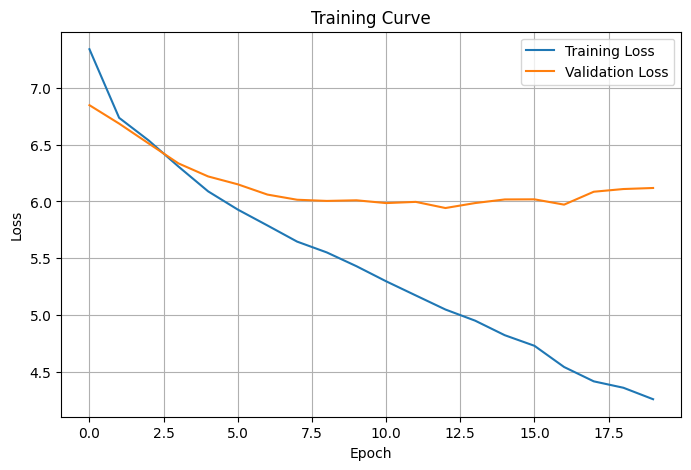

In [35]:
# ============================================================
# Plot Training Curve
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(train_losses,label="Training Loss")
plt.plot(valid_losses,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
torch.save(
    model.state_dict(),
    "final_model.pt"
)

In [37]:
import heapq

# ============================================================
# Beam Search Decoding
# ============================================================

def beam_search_decode(model,sentence,src_vocab,tgt_vocab,beam_width=8,max_len=50):
  model.eval()
  tokens = tokenize(clean_sanskrit(sentence))
  src_indexes = [src_vocab.word2idx[SOS_TOKEN]]
  src_indexes += [
      src_vocab.word2idx.get(
      token,
      src_vocab.word2idx[UNK_TOKEN]
      )
      for token in tokens
  ]
  src_indexes.append(src_vocab.word2idx[EOS_TOKEN])
  src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)
  src_lengths = torch.LongTensor([len(src_indexes)])
  with torch.no_grad():
    encoder_outputs, hidden, cell = model.encoder(
        src_tensor,
        src_lengths
    )

  mask = model.create_mask(src_tensor)
  beams = [
      (
          0.0,
          [tgt_vocab.word2idx[SOS_TOKEN]],
          hidden,
          cell
      )
  ]
  completed = []
  alpha = 0.7
  for _ in range(max_len):
    candidates = []
    for score, seq, h, c in beams:
      last_token = seq[-1]
      if last_token == tgt_vocab.word2idx[EOS_TOKEN]:
        completed.append((score / ((5 + len(seq))**alpha / (5+1)**alpha), seq))
        continue

      input_token = torch.LongTensor([last_token]).to(device)
      with torch.no_grad():
        output, new_hidden, new_cell = model.decoder(
            input_token,
            h,
            c,
            encoder_outputs,
            mask
        )
      log_probs = torch.log_softmax(output, dim=1)
      topk = torch.topk(log_probs, beam_width)
      for k in range(beam_width):
        token = topk.indices[0][k].item()
        token_score = topk.values[0][k].item()
        candidates.append(
            (
                score + token_score,
                seq + [token],
                new_hidden.clone(),
                new_cell.clone()
            )
        )
    beams = heapq.nlargest(
        beam_width,
        candidates,
        key=lambda x: x[0]
    )
    if len(beams) == 0:
      break

  if len(completed) == 0:
    completed = beams

  best=max(
      completed,
      key=lambda x: x[0] / max(1, len(x[1]))
  )
  translation = []
  for idx in best[1]:
    word = tgt_vocab.idx2word[idx]
    if word in [SOS_TOKEN, EOS_TOKEN, PAD_TOKEN]:
        continue

    translation.append(word)
  return translation

In [38]:
# ============================================================
# Translate One Sentence
# ============================================================

def translate_sentence(sentence):
  prediction = beam_search_decode(model,sentence,src_vocab,tgt_vocab,beam_width=8)
  prediction = [
      word
      for word in prediction
      if word not in
      (
          PAD_TOKEN,
          SOS_TOKEN,
          EOS_TOKEN
      )
  ]
  prediction = " ".join(prediction)
  prediction = re.sub(
      r"\s+",
      " ",
      prediction
  ).strip()
  return prediction

In [40]:
predictions = []
references = []

for _, row in tqdm(test.iterrows(), total=len(test)):
  prediction = translate_sentence(row["Sentence_sa"])
  predictions.append(tokenize(clean_english(prediction)))
  references.append(
      [tokenize(clean_english(row["Sentence_en"]))]
  )

  0%|          | 0/1000 [00:00<?, ?it/s]

In [41]:
# ============================================================
# BLEU Score
# ============================================================

from nltk.translate.bleu_score import (
    corpus_bleu,
    SmoothingFunction
)

smoothie = SmoothingFunction().method4
bleu = corpus_bleu(
    references,
    predictions,
    smoothing_function=smoothie
)
print("=" * 40)
print(f"BLEU Score : {bleu:.4f}")
print("=" * 40)

BLEU Score : 0.0083


In [42]:
import heapq

# ============================================================
# BERTScore
# ============================================================

reference_sentences = [
    clean_english(x)
    for x in test["Sentence_en"]
]
predictions_for_bert_score = [" ".join(p) for p in predictions]
filtered_predictions = []
filtered_references = []
for pred_str, ref_str in zip(predictions_for_bert_score, reference_sentences):
  if pred_str.strip() and ref_str.strip():
    filtered_predictions.append(pred_str)
    filtered_references.append(ref_str)

P, R, F1 = bert_score(
    filtered_predictions,
    filtered_references,
    model_type='bert-base-uncased',
    lang="en",
    rescale_with_baseline=True,
    use_fast_tokenizer=False
)
print("=" * 40)
print(f"BERTScore F1 : {F1.mean().item():.4f}")
print("=" * 40)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore F1 : 0.0817


In [43]:
# ============================================================
# Parameter Count
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)
print("=" * 40)
print(f"Trainable Parameters : {total_params:,}")
print("=" * 40)

Trainable Parameters : 60,767,955


In [44]:
# ============================================================
# Inference Time
# ============================================================

start = time.time()
translated_sentences = []
for sentence in test["Sentence_sa"]:
  translated = translate_sentence(sentence)
  translated = re.sub(
      r"\s+",
      " ",
      translated
  ).strip()
  translated_sentences.append(
      translated
  )

end = time.time()
print("=" * 40)
print(f"Inference Time : {end-start:.2f} seconds")
print("=" * 40)

Inference Time : 447.08 seconds


In [45]:
# ============================================================
# Generate Submission
# ============================================================

submission = pd.DataFrame({
    "Source_id": test["Source_id"],
    "Sentence_en": translated_sentences
})
submission.to_csv(
    "submission.csv",
    index=False,
    encoding="utf-8"
)
print(submission.head())
print("\nsubmission.csv generated successfully.")

   Source_id                                        Sentence_en
0          1  in this tutorial we have learnt how to the fol...
1          2  in this is a new of the and of the the of the ...
2          3  let us go to learn how to add a particular lin...
3          4  in this tutorial we will learn how to create a...
4          5  and i say unto you should be able to be able t...

submission.csv generated successfully.


In [46]:
# ============================================================
# Sample Predictions
# ============================================================

for i in range(10):
  print("=" * 80)
  print("Sanskrit :")
  print(test.iloc[i]["Sentence_sa"])
  print()
  print("Reference :")
  print(test.iloc[i]["Sentence_en"])
  print()
  print("Prediction :")
  print(translated_sentences[i])
  print("=" * 80)

Sanskrit :
एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति

Reference :
eclipse also helps the programmer to find out errors

Prediction :
in this tutorial we have learnt how to the following method in this tutorial i am using ubuntu linux os as shown in this tutorial i am using ubuntu linux os and to the following method in this tutorial i am using ubuntu linux os as shown
Sanskrit :
विश्वासकारणादेव समभाषि मया वचः इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मानं प्राप्य विश्वासः क्रियते तस्माच्च वचांसि भाष्यन्ते

Reference :
we having the same spirit of faith according as it is written i believed and therefore have i spoken we also believe and therefore speak

Prediction :
in this is a new of the and of the the of the and of the the of this is not in this lesson you may be able to be able to be able to be able to be able to be able to be able to the
Sanskrit :
तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति अहं 'Cancel' इत्यस्योपरि नुदामि

Reference :
then it will a